# 作业四：机器翻译计算BLEU
姓名：杨希渊
学号：524531910015

## 加载模型和Tokenizer

本次作业将使用从huggingface中下载德英翻译模型`Helsinki-NLP/opus-mt-en-de`进行翻译测试，无需大家自行训练模型

In [81]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, MarianTokenizer
from collections import Counter
import math

# Load model and tokenizer
tokenizer = MarianTokenizer.from_pretrained(pretrained_model_name_or_path="/data/xiyuanyang/My-NLP/models/opus-mt-en-de")
model = AutoModelForSeq2SeqLM.from_pretrained(pretrained_model_name_or_path="/data/xiyuanyang/My-NLP/models/opus-mt-en-de")

/data/xiyuanyang/My-NLP/.venv/lib/python3.13/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 15975.94it/s]


### Tokenizer

> 下面是一个例子，展示Tokenizer和模型的使用。理解下面的例子可能对你的作业有帮助。

```python

Tokenizer会将句子分割成一个个token，然后将每个token转化为一个数字，这个数字就是这个token在词表中的id。

In [82]:
# Sample English sentence
sentence = "Good morning! How are you?"
inputs = tokenizer.encode(sentence, return_tensors="pt")
print(inputs)

tensor([[2628, 2973,   68,  650,   48,   41,   31,    0]])


可以将token id映射到对应的分词token

In [83]:
tokens = tokenizer.convert_ids_to_tokens(inputs[0])
print(tokens)

['▁Good', '▁morning', '!', '▁How', '▁are', '▁you', '?', '</s>']


可以使用`decode`方法将token id转化回原来的句子

In [84]:
decoded_string = tokenizer.decode(inputs[0])
print(decoded_string)

Good morning! How are you?</s>


## 计算BLEU score

BLEU 是机器翻译评估中最常用的指标之一。

核心思想：

- 一个好的翻译结果，应该在 n-gram 上尽可能和参考翻译重叠。
- 为了避免模型生成过短的翻译，BLEU 引入了 简短惩罚（Brevity Penalty, BP）。

计算公式为：
$$
BLEU = BP \cdot \exp(\sum^N_{n=1} w_n \log p_n)
$$
其中：

- $p_n$：n-gram 的修正精确率（modified precision）
- $w_n$：权重（通常取均匀分布，$w_n = 1/N$）
- BP：简短惩罚，定义如下
$$
B P= \begin{cases}1 & \text { if } c>r \\ \exp \left(1-\frac{r}{c}\right) & \text { if } c \leq r\end{cases}
$$

- $c$：候选翻译的长度
- $r$：参考翻译的长度（取最接近候选翻译长度的参考）

### n-gram提取

In [85]:

def ngram_counts(tokens, n):
    """
    从一个分词后的句子中提取所有 n-gram，并统计频数。
    
    参数:
        tokens (list): 句子的分词结果
        n (int): n-gram 的阶数
    
    返回:
        Counter: n-gram -> 出现次数
    """
    counts = Counter()
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        counts[ngram] += 1
    return counts

### 修正精确率（modified precision）

In [86]:
def modified_precision(candidate, references, n):
    """
    计算 n-gram 的修正精确率。
    
    参数:
        candidate (list): 候选翻译（分词后的列表）
        references (list of list): 多个参考翻译（每个参考为一个分词列表）
        n (int): n-gram 阶数
    
    返回:
        (clipped_count, total_count): clip 后的匹配数量与候选总数
    """
    cand_ngrams = ngram_counts(candidate, n)
    max_ref_counts = Counter()

    # 计算所有参考翻译中的最大 n-gram 计数
    for ref in references:
        ref_ngrams = ngram_counts(ref, n)
        for ng, count in ref_ngrams.items():
            if ng in max_ref_counts:
                max_ref_counts[ng] = max(max_ref_counts[ng], count)
            else:
                max_ref_counts[ng] = count

    # 对候选中的 n-gram 进行截断计数
    clipped = {ng: min(count, max_ref_counts[ng]) for ng, count in cand_ngrams.items()}
    
    # 返回匹配与候选的总数
    clipped_count = sum(clipped.values())
    total_count = sum(cand_ngrams.values())
    return clipped_count, total_count

### 简短惩罚（Brevity Penalty）

In [87]:
def brevity_penalty(candidate, references):
    """
    计算简短惩罚 (BP)。
    
    参数:
        candidate (list): 候选翻译
        references (list of list): 参考翻译列表
    
    返回:
        float: BP 值
    """
    c = len(candidate)
    ref_lens = [len(ref) for ref in references]
    # 选择与候选长度最接近的参考长度
    r = min(ref_lens, key=lambda x: abs(x - c))
    
    # 计算BP值
    if c > r:
        return 1.0
    else:
        return math.exp(1 - r / c)

### BLEU分数

In [88]:
def bleu_score(candidate, references, max_n=4):
    """
    计算 BLEU 分数（默认 BLEU-4）。
    
    参数:
        candidate (list): 候选翻译
        references (list of list): 参考翻译
        max_n (int): 最大 n-gram 阶数（默认为 4）
    
    返回:
        float: BLEU 分数
    """
    # 计算简短惩罚
    bp = brevity_penalty(candidate, references)
    
    # 计算各阶 n-gram 的精确率
    log_precisions = []
    weights = [1.0 / max_n] * max_n
    
    for n in range(1, max_n + 1):
        clipped_count, total_count = modified_precision(candidate, references, n)
        if total_count == 0 or clipped_count == 0:
            log_p = float('-inf')
        else:
            log_p = math.log(clipped_count / total_count)
        log_precisions.append(log_p)
    
    # 处理无法计算的情况
    if any(p == float('-inf') for p in log_precisions):
        return 0.0
    
    # 计算加权和
    weighted_sum = sum(w * p for w, p in zip(weights, log_precisions))
    
    # 计算BLEU分数
    bleu = bp * math.exp(weighted_sum)
    return bleu

## 测试与总结（6分）

### Sample 1

In [89]:
sentence = "The weather is nice today."
references = [
    ["Das", "Wetter", "ist", "heute", "schön", "."],
    ["Heute", "ist", "das", "Wetter", "schön", "."]
]

# Translate English to Deutsch (German)
inputs = tokenizer.encode(sentence, return_tensors="pt")
outputs = model.generate(inputs, max_length=40, num_beams=4, early_stopping=True)
translated_sentence = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Translated Sentence:", translated_sentence)

print("Sample-1 BLEU-1:", bleu_score(translated_sentence.split(), references, max_n=1))
print("Sample-1 BLEU-2:", bleu_score(translated_sentence.split(), references, max_n=2))
print("Sample-1 BLEU-4:", bleu_score(translated_sentence.split(), references, max_n=4))


Translated Sentence: Das Wetter ist heute schön.
Sample-1 BLEU-1: 0.6549846024623855
Sample-1 BLEU-2: 0.6341861143397762
Sample-1 BLEU-4: 0.5475182535069453


### Sample 2

In [90]:
sentence = "The conference will take place in Berlin next week, and many researchers from different countries are expected to attend."
references = [
    ["Die", "Konferenz", "findet", "nächste", "Woche", "in", "Berlin", "statt", ",", "und", "es", "wird", "erwartet", ",", "dass", "viele", "Forscher", "aus", "verschiedenen", "Ländern", "teilnehmen", "."],
    ["Nächste", "Woche", "wird", "die", "Konferenz", "in", "Berlin", "abgehalten", ",", "wobei", "zahlreiche", "Wissenschaftler", "aus", "unterschiedlichen", "Ländern", "erwartet", "werden", "."],
    ["Die", "Konferenz", "wird", "nächste", "Woche", "in", "Berlin", "stattfinden", ",", "und", "viele", "Forscher", "aus", "anderen", "Ländern", "sollen", "daran", "teilnehmen", "."]
]

# Translate English to Deutsch (German)
inputs = tokenizer.encode(sentence, return_tensors="pt")
outputs = model.generate(inputs, max_length=64, num_beams=4, early_stopping=True)
translated_sentence = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Translated Sentence:", translated_sentence.split())

print("Sample-2 BLEU-1:", bleu_score(translated_sentence.split(), references, max_n=1))
print("Sample-2 BLEU-2:", bleu_score(translated_sentence.split(), references, max_n=2))
print("Sample-2 BLEU-4:", bleu_score(translated_sentence.split(), references, max_n=4))


Translated Sentence: ['Die', 'Konferenz', 'findet', 'nächste', 'Woche', 'in', 'Berlin', 'statt,', 'an', 'der', 'viele', 'Forscher', 'aus', 'verschiedenen', 'Ländern', 'teilnehmen', 'werden.']
Sample-2 BLEU-1: 0.7210206394184336
Sample-2 BLEU-2: 0.683654745092498
Sample-2 BLEU-4: 0.5941900332409864


### Sample 3

In [91]:
sentence = "Artificial intelligence is rapidly developing, and it is increasingly being applied in areas such as healthcare, education, and autonomous driving."
references = [
    ["Die", "künstliche", "Intelligenz", "entwickelt", "sich", "rasant", "und", "wird", "zunehmend", "in", "Bereichen", "wie", "Gesundheitswesen", ",", "Bildung", "und", "autonomes", "Fahren", "eingesetzt", "."],
    ["Künstliche", "Intelligenz", "macht", "schnelle", "Fortschritte", "und", "findet", "immer", "häufiger", "Anwendung", "im", "Gesundheitswesen", ",", "in", "der", "Bildung", "und", "im", "autonomen", "Fahren", "."],
    ["Künstliche", "Intelligenz", "entwickelt", "sich", "schnell", "und", "wird", "mehr", "in", "Medizin", ",", "Schulen", "und", "selbstfahrenden", "Autos", "benutzt", "."]
]

# Translate English to Deutsch (German)
inputs = tokenizer.encode(sentence, return_tensors="pt")
outputs = model.generate(inputs, max_length=40, num_beams=5, early_stopping=True)
translated_sentence = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Translated Sentence:", translated_sentence)

print("Sample-3 BLEU-1:", bleu_score(translated_sentence.split(), references, max_n=1))
print("Sample-3 BLEU-2:", bleu_score(translated_sentence.split(), references, max_n=2))
print("Sample-3 BLEU-4:", bleu_score(translated_sentence.split(), references, max_n=4))


Translated Sentence: Künstliche Intelligenz entwickelt sich rapide und wird zunehmend in Bereichen wie Gesundheitswesen, Bildung und autonomes Fahren eingesetzt.
Sample-3 BLEU-1: 0.8235294117647058
Sample-3 BLEU-2: 0.7524469885568253
Sample-3 BLEU-4: 0.573057404379869


## 实验总结分析

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 扩展测试样本集
test_samples = [
    {
        "sentence": "The weather is nice today.",
        "references": [
            ["Das", "Wetter", "ist", "heute", "schön", "."],
            ["Heute", "ist", "das", "Wetter", "schön", "."],
            ["Das", "Wetter", "wird", "heute", "gut", "."],
        ]
    },
    {
        "sentence": "The conference will take place in Berlin next week.",
        "references": [
            ["Die", "Konferenz", "findet", "nächste", "Woche", "in", "Berlin", "statt", "."],
            ["Nächste", "Woche", "wird", "die", "Konferenz", "in", "Berlin", "abgehalten", "."],
            ["Die", "Konferenz", "wird", "nächste", "Woche", "in", "Berlin", "stattfinden", "."],
        ]
    },
    {
        "sentence": "Artificial intelligence is rapidly developing.",
        "references": [
            ["Die", "künstliche", "Intelligenz", "entwickelt", "sich", "rasant", "."],
            ["Künstliche", "Intelligenz", "macht", "schnelle", "Fortschritte", "."],
            ["Künstliche", "Intelligenz", "entwickelt", "sich", "schnell", "."],
        ]
    },
    {
        "sentence": "I like reading books in the library.",
        "references": [
            ["Ich", "lese", "gern", "Bücher", "in", "der", "Bibliothek", "."],
            ["Ich", "lese", "gerne", "in", "der", "Bibliothek", "Bücher", "."],
            ["In", "der", "Bibliothek", "lese", "ich", "gern", "Bücher", "."],
        ]
    }
]

# 批量翻译和计算BLEU分数
results = {
    "sample_names": [],
    "translated": [],
    "bleu1": [],
    "bleu2": [],
    "bleu4": []
}

print("=" * 80)
print("批量实验结果")
print("=" * 80)

for idx, sample in enumerate(test_samples, 1):
    # 翻译
    inputs = tokenizer.encode(sample["sentence"], return_tensors="pt")
    outputs = model.generate(inputs, max_length=64, num_beams=4, early_stopping=True)
    translated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # 计算BLEU分数
    bleu1 = bleu_score(translated.split(), sample["references"], max_n=1)
    bleu2 = bleu_score(translated.split(), sample["references"], max_n=2)
    bleu4 = bleu_score(translated.split(), sample["references"], max_n=4)
    
    # 保存结果
    results["sample_names"].append(f"Sample {idx}")
    results["translated"].append(translated)
    results["bleu1"].append(bleu1)
    results["bleu2"].append(bleu2)
    results["bleu4"].append(bleu4)
    
    # 打印结果
    print(f"\n【Sample {idx}】")
    print(f"原文: {sample['sentence']}")
    print(f"译文: {translated}")
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

print("\n" + "=" * 80)
print("统计摘要")
print("=" * 80)
print(f"BLEU-1 平均值: {np.mean(results['bleu1']):.4f} ± {np.std(results['bleu1']):.4f}")
print(f"BLEU-2 平均值: {np.mean(results['bleu2']):.4f} ± {np.std(results['bleu2']):.4f}")
print(f"BLEU-4 平均值: {np.mean(results['bleu4']):.4f} ± {np.std(results['bleu4']):.4f}")

批量实验结果

【Sample 1】
原文: The weather is nice today.
译文: Das Wetter ist heute schön.
BLEU-1: 0.6550
BLEU-2: 0.6342
BLEU-4: 0.5475

【Sample 2】
原文: The conference will take place in Berlin next week.
译文: Die Konferenz findet nächste Woche in Berlin statt.
BLEU-1: 0.7722
BLEU-2: 0.7643
BLEU-4: 0.7421

【Sample 3】
原文: Artificial intelligence is rapidly developing.
译文: Künstliche Intelligenz entwickelt sich rasant.
BLEU-1: 0.6550
BLEU-2: 0.6342
BLEU-4: 0.5475

【Sample 4】
原文: I like reading books in the library.
译文: Ich lese gern Bücher in der Bibliothek.
BLEU-1: 0.7430
BLEU-2: 0.7326
BLEU-4: 0.7014

统计摘要
BLEU-1 平均值: 0.7063 ± 0.0523
BLEU-2 平均值: 0.6913 ± 0.0582
BLEU-4 平均值: 0.6346 ± 0.0883


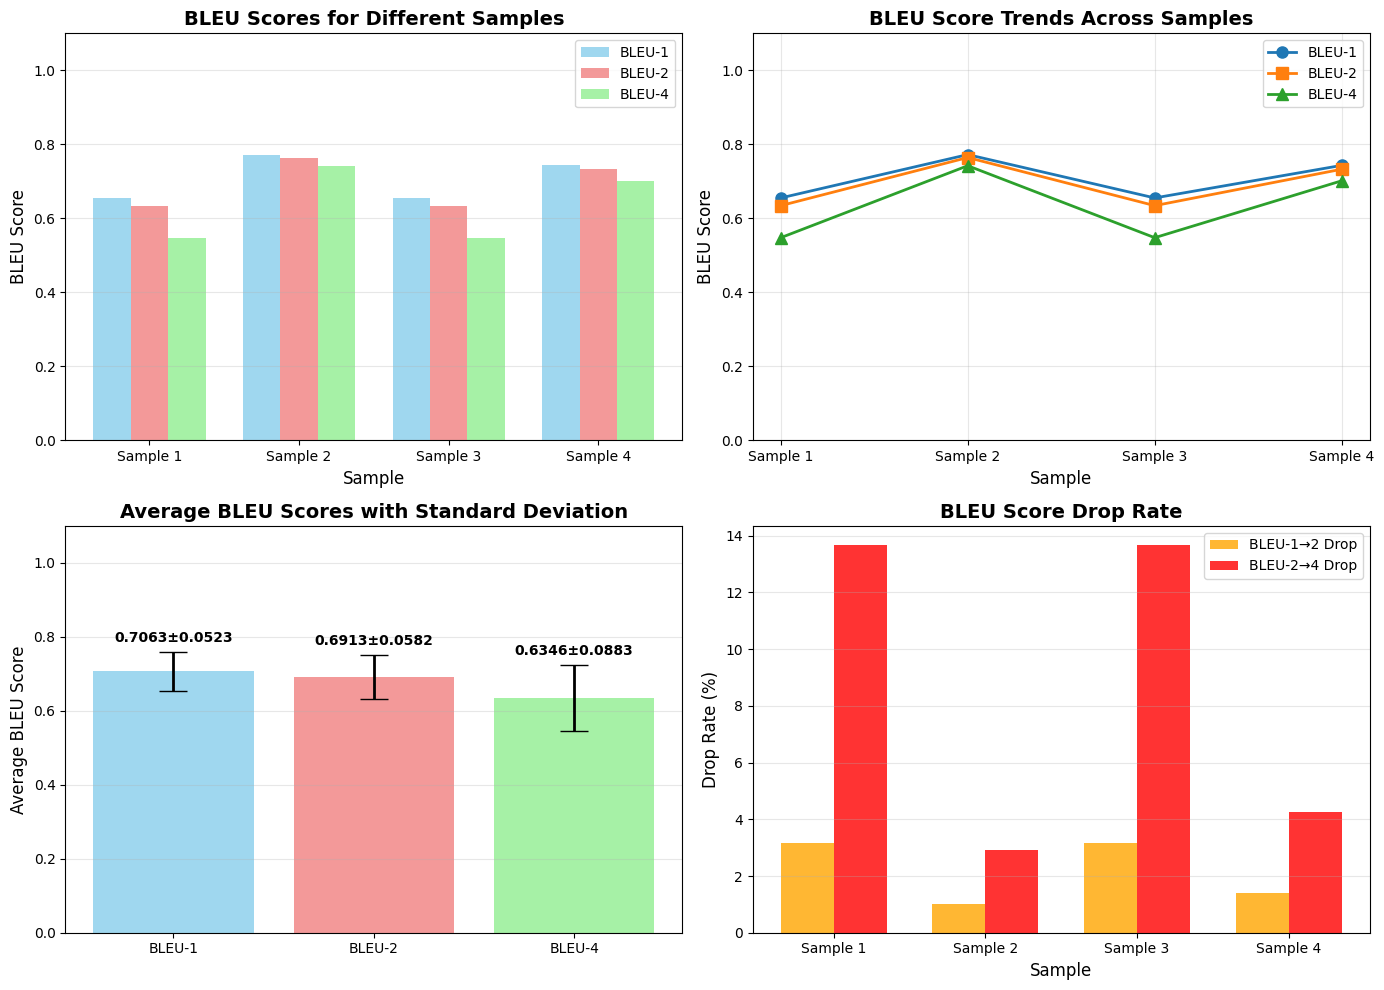

In [93]:
# 可视化BLEU分数
plt.figure(figsize=(14, 10))

# 子图1: 各样本的BLEU分数对比（柱状图）
plt.subplot(2, 2, 1)
x = np.arange(len(results["sample_names"]))
width = 0.25
plt.bar(x - width, results["bleu1"], width, label='BLEU-1', color='skyblue', alpha=0.8)
plt.bar(x, results["bleu2"], width, label='BLEU-2', color='lightcoral', alpha=0.8)
plt.bar(x + width, results["bleu4"], width, label='BLEU-4', color='lightgreen', alpha=0.8)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('BLEU Score', fontsize=12)
plt.title('BLEU Scores for Different Samples', fontsize=14, fontweight='bold')
plt.xticks(x, results["sample_names"])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)

# 子图2: BLEU分数趋势折线图
plt.subplot(2, 2, 2)
plt.plot(results["sample_names"], results["bleu1"], marker='o', label='BLEU-1', linewidth=2, markersize=8)
plt.plot(results["sample_names"], results["bleu2"], marker='s', label='BLEU-2', linewidth=2, markersize=8)
plt.plot(results["sample_names"], results["bleu4"], marker='^', label='BLEU-4', linewidth=2, markersize=8)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('BLEU Score', fontsize=12)
plt.title('BLEU Score Trends Across Samples', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.1)

# 子图3: 平均BLEU分数对比
plt.subplot(2, 2, 3)
avg_scores = [np.mean(results["bleu1"]), np.mean(results["bleu2"]), np.mean(results["bleu4"])]
std_scores = [np.std(results["bleu1"]), np.std(results["bleu2"]), np.std(results["bleu4"])]
colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(['BLEU-1', 'BLEU-2', 'BLEU-4'], avg_scores, yerr=std_scores, 
                color=colors, alpha=0.8, capsize=10, error_kw={'linewidth': 2})
plt.ylabel('Average BLEU Score', fontsize=12)
plt.title('Average BLEU Scores with Standard Deviation', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)

# 在柱子上显示数值
for i, (bar, avg, std) in enumerate(zip(bars, avg_scores, std_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02, 
             f'{avg:.4f}±{std:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 子图4: BLEU分数下降率
plt.subplot(2, 2, 4)
bleu1_arr = np.array(results["bleu1"])
bleu2_arr = np.array(results["bleu2"])
bleu4_arr = np.array(results["bleu4"])
drop_rate_2 = ((bleu1_arr - bleu2_arr) / bleu1_arr) * 100
drop_rate_4 = ((bleu2_arr - bleu4_arr) / bleu2_arr) * 100

x = np.arange(len(results["sample_names"]))
width = 0.35
plt.bar(x - width/2, drop_rate_2, width, label='BLEU-1→2 Drop', color='orange', alpha=0.8)
plt.bar(x + width/2, drop_rate_4, width, label='BLEU-2→4 Drop', color='red', alpha=0.8)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Drop Rate (%)', fontsize=12)
plt.title('BLEU Score Drop Rate', fontsize=14, fontweight='bold')
plt.xticks(x, results["sample_names"])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 实验分析

- BLEU-1 分数 > BLEU-2 分数 > BLEU-4 分数：这和 BLEU 数学计算公式相符合
- 随着n-gram阶数增加，匹配难度增大，分数下降
- 不同样本的BLEU分数差异反映了翻译质量的波动
- 简短句子可能受长度惩罚影响较小